## Principal Component Analysis

So far, we've been dealing with data whose underlying patterns can be found through a relationship between inputs $x$ and outputs $y$: $y = f(x)$. However, what happens if the data doesn't have a clear output, and we're merely interested in identifying intrinsic patterns within the data itself? This scenario is a prime domain for unsupervised learning methods.

Within unsupervised learning, one renowned example is Clustering, which aims to group similar data points together. Another pivotal method is Principal Component Analysis (PCA), the central theme of this discourse. PCA serves as a powerful tool for dimensionality reduction, enabling us to simplify the data without forfeiting its intrinsic structure and variability.

PCA accomplishes this by identifying the principal components, which are the key directions along which the data exhibits the most substantial variance. Mathematically, these directions correspond to the eigenvectors of the data's covariance matrix, while the associated eigenvalues quantify the extent of variance along each direction.

To delve deeper into the mechanics of PCA, let's consider a dataset $\{\mathbf x_i; i=1,\ldots, m\}$, which we can stack a matrix $X$, where each row corresponds to an observation and each column to a variable:

$$
X = \begin{bmatrix}
\mathbf{x}_1 \\
\mathbf{x}_2 \\
\vdots \\
\mathbf{x}_m
\end{bmatrix}
$$


Here, each $\mathbf{x}_i$ is detailed as:

$$
\mathbf{x}_i = \begin{bmatrix}
x_{i1} & x_{i2} & \cdots & x_{in}
\end{bmatrix}
$$

Thus, the matrix $X$ can be expressed as:

$$
X = \begin{bmatrix}
x_{11} & x_{12} & \cdots & x_{1n} \\
x_{21} & x_{22} & \cdots & x_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
x_{m1} & x_{m2} & \cdots & x_{mn}
\end{bmatrix}
$$

For PCA, we often start by centering the data, ensuring each feature has a zero mean. Centering is crucial because it aligns the data with the coordinate axes, making the identification of the principal components easier.

$$
\begin{align*}
\bar{\mathbf{x}} &= \frac{1}{m} \sum_{i=1}^{m} \mathbf{x}_i \\
\mathbf{x}_i &\leftarrow \mathbf{x}_i - \bar{\mathbf{x}}
\end{align*}
$$

where $\bar{\mathbf{x}}$ is the mean of the data. Having centered the data, it is often useful to normalize the data as well, ensuring that each feature has a unit variance. This step is particularly important when the features are measured in different units or have different scales.

$$
\begin{align*}
\sigma_j^2 &= \frac{1}{m-1} \sum_{i=1}^{m} x_{ij}^2 \\
x_{ij} &\leftarrow \frac{x_{ij}}{\sigma_j}
\end{align*}
$$


The covariance matrix $\Sigma$ of $X$, crucial for PCA, can be derived from the product $X^TX$. This product accumulates the outer products of each row vector $\mathbf{x}_i$ with itself:

$$
X^TX = \sum_{i=1}^{m} \mathbf{x}_i^T\mathbf{x}_i
$$

which is effectively the covariance matrix $\Sigma$, where each entry denotes the covariance between pairs of features across all observations. Specifically, for a centered dataset, the covariance between two different features $j$ and $k$ across all observations is captured as:

$$
\Sigma_{jk} = \frac{1}{m-1} \sum_{i=1}^{m} x_{ij}x_{ik}
$$

Subsequently, PCA seeks to find the eigenvectors and eigenvalues of this covariance matrix, which reveal the principal components and their respective variances. The eigenvector associated with the highest eigenvalue points in the direction of greatest variance in the data, earmarking the first principal component. Sequential principal components are similarly identified, each orthogonal to the preceding ones, encapsulating successively lesser variances.

By projecting the original data onto these principal components, we achieve a dimensionality-reduced representation that retains the most critical aspects of variance present in the original dataset. This transformation not only aids in visualization but also enhances the efficiency of subsequent analytical or machine learning tasks.

To identify the principal components, we seek the directions (vectors) along which the data exhibits the maximum variance in the distances of the projected vectors $\mathbf{x}_i$ from the origin. We can find the length of each projection on a unit vector $\mathbf u$ through the dot product $\mathbf u^T\mathbf x_i$. The variance of these projections is then given by:

$$
\begin{align*}
\frac{1}{m-1} \sum_{i=1}^{m} (\mathbf u^T\mathbf x_i)^2 &= \mathbf u^T\left(\frac{1}{m-1} \sum_{i=1}^{m} \mathbf x_i\mathbf x_i^T\right)\mathbf u \\
&= \mathbf u^T\Sigma\mathbf u
\end{align*}
$$

Or

$$
\max_{\|u\|=1} u^T\Sigma u
$$

This constrained optimization problem can be solved using Lagrange Multipliers which can be defined as:
$$
L(u, \lambda) = u^T\Sigma u - \lambda(u^Tu - 1) 
$$

Since we're optimizing with respect to $u$, we can set the derivative of $L$ with respect to $u$ to zero:
$$
\begin{align*}
\frac{\partial L}{\partial u} &= 2\Sigma u - 2\lambda u = 0 \\
\Sigma u &= \lambda u
\end{align*}
$$

In other words, the principal components are the eigenvectors of the covariance matrix $\Sigma$. The eigenvalues of $\Sigma$ quantify the variance along each principal component, and the eigenvectors provide the directions of these principal components. The principal components are ordered by the magnitude of their corresponding eigenvalues, with the first principal component capturing the most variance, the second principal component capturing the second most variance, and so on. 

### Relationship to Singular Value Decomposition

While PCA fundamentally revolves around identifying the eigenvectors and eigenvalues of the covariance matrix, in practice, this process is commonly executed through Singular Value Decomposition (SVD) for better computational stability and efficiency, especially with large datasets. The use of SVD to perform PCA is motivated by the computational challenges and numerical instability that can arise when directly calculating the eigendecomposition of the covariance matrix, particularly for high-dimensional data.

SVD decomposes any matrix $X$, which has been centered (zero mean for each feature), into three matrices:

$$
X = U \Xi V^T
$$

Where:
- $U$ is an $m \times m$ orthogonal matrix where the columns are the left singular vectors of $X$.
- $\Xi$ is an $m \times n$ diagonal matrix with non-negative real numbers on the diagonal known as singular values, sorted in descending order.
- $V$ is an $n \times n$ orthogonal matrix where the columns are the right singular vectors of $X$, and also corresponds to the eigenvectors of $X^TX$.

Now, to understand the relationship between SVD and PCA, we can analyze how these matrices relate to the covariance matrix $\Sigma$ of the dataset $X$. When you perform PCA, you are essentially computing the covariance matrix $\Sigma = \frac{1}{m-1} X^T X$. If we substitute the SVD of $X$ into this equation, we get:

$$
\Sigma = \frac{1}{m-1} (U \Xi V^T)^T (U \Xi V^T) = \frac{1}{m-1} V \Xi^T U^T U \Xi V^T
$$

Since $U$ is an orthogonal matrix, $U^T U$ equals the identity matrix $I$, simplifying the equation to:

$$
\Sigma = \frac{1}{m-1} V \Xi^T \Xi V^T = \frac{1}{m-1} V \Xi^2 V^T
$$

Which can be rewritten as:

$$
\Sigma V = V \Xi_m^2
$$

The matrix $\Xi_m^2$ contains the singular values squared and scaled by $1/(m-1)$, corresponding to the eigenvalues of the covariance matrix $\Sigma$. The columns of $V$ are indeed the eigenvectors of $\Sigma$.

In the PCA context, the columns of $V$ (right singular vectors) represent the principal components, and the singular values in $\Sigma$ are related to the variance captured by each principal component. Specifically, the magnitude of each singular value indicates the importance of its corresponding principal component; larger singular values correspond to more significant principal components.

Therefore, to find the principal components of $X$, one can use the SVD and take the matrix $V$. The columns of $V$, up to the desired number of principal components, provide the directions or axes along which the data varies the most. This approach avoids direct computation of the covariance matrix and its eigendecomposition, leveraging the numerical stability and efficiency of SVD.

By projecting the original data $X$ onto the principal components (the columns of $V$), we obtain a reduced representation of the data in the principal component space, facilitating dimensionality reduction while retaining the essence of the data's variability. This is why, in practical applications, PCA is often implemented through SVD, optimizing both computational stability and interpretability of the results.

## A Simple Example

Let's illustrate the PCA process with a simple example. We'll generate a synthetic dataset and apply PCA to identify the principal components and visualize the dimensionality reduction.

To do that we will generate a synthetic dataset with 2 features and 100 samples. We will then apply PCA to reduce the dimensionality of the dataset from 2 to 1.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Generating a synthetic 2D dataset
# Creating a dataset with a clear direction of maximum variance
x = 3 + np.random.normal(loc=0.0, scale=1.0, size=100)
y = 5 + 2.5 * x + np.random.normal(loc=0.0, scale=0.5, size=100)
data = np.vstack([x, y]).T

Once we have the reduced dataset, we will visualize the original and reduced datasets to understand how PCA has transformed the data.

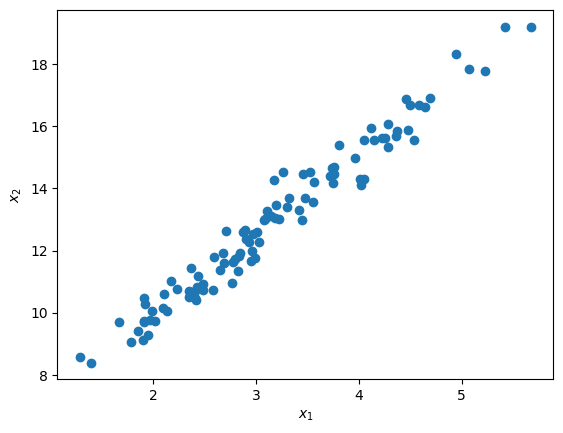

In [2]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)
plt.scatter(data[:,0], data[:,1])
plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.show()


The next step is center the data, and potentially normalize it. We then calculate the SVD of the centered data and use the right singular vectors to identify the principal components. Finally, we project the original data onto the principal components to obtain the reduced representation, using the fact that the principles components are given by

$$
T = XV = U\Xi
$$



In [3]:

# Performing SVD on the zero-mean data
data_mean = np.mean(data, axis=0)
data_centered = data - data_mean
U, S, Vt = np.linalg.svd(data_centered)

# Transforming data into the principal component space
data_pca = np.dot(data_centered, Vt.T)


Finally, we plot the data:

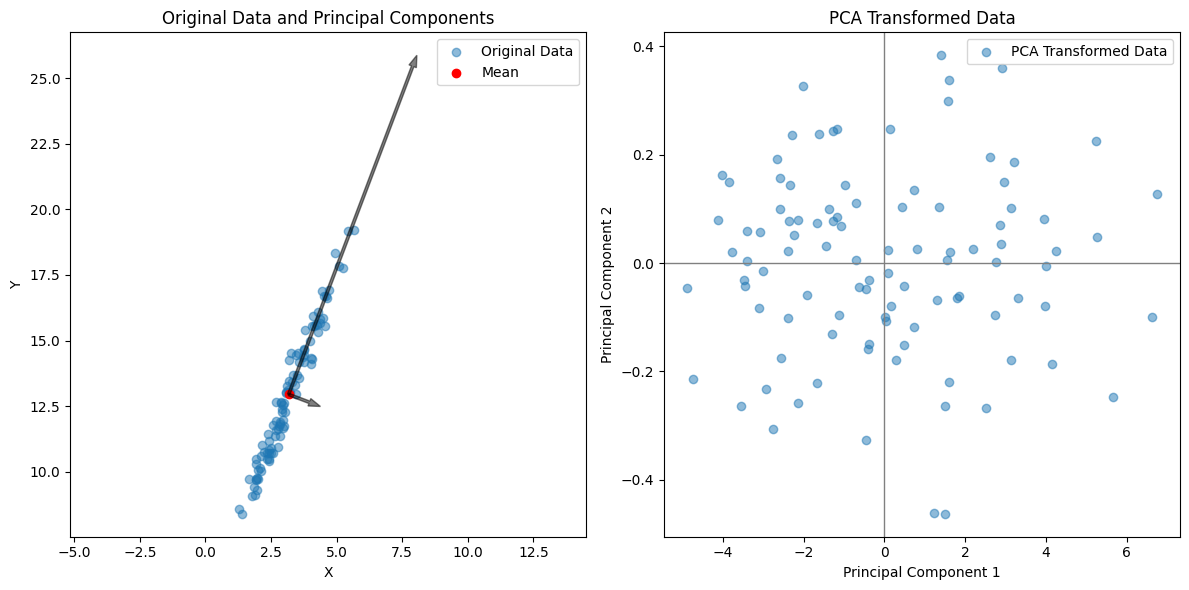

In [4]:

# Plotting the original data, mean, principal components, and transformed data
plt.figure(figsize=(12, 6))

# Original data and mean
plt.subplot(1, 2, 1)
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label='Original Data')
plt.scatter(data_mean[0], data_mean[1], color='red', label='Mean')
for i, s in enumerate(S):
    plt.arrow(data_mean[0], data_mean[1], Vt[i, 0] * s/2, Vt[i, 1] * s/2, width=0.1, color='k', alpha=0.5)
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Original Data and Principal Components')
plt.axis('equal')  # Setting equal scaling on both axes

plt.legend()

# Transformed data
plt.subplot(1, 2, 2)
plt.scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.5, label='PCA Transformed Data')
plt.axhline(0, color='grey', lw=1)
plt.axvline(0, color='grey', lw=1)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Transformed Data')
plt.legend()


plt.tight_layout()
plt.show()
